# NLP Zero To Hero Part 6: Training an AI to Create Poetry

In [1]:
import tensorflow as tf

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np 

In [2]:
!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/irish-lyrics-eof.txt \
    -O /tmp/irish-lyrics-eof.txt

--2026-09-12 14:44:53--  https://storage.googleapis.com/learning-datasets/irish-lyrics-eof.txt
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.218.27, 142.251.40.123, 142.251.215.91, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.218.27|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68970 (67K) [text/plain]
Saving to: '/tmp/irish-lyrics-eof.txt'

/tmp/irish-lyrics-e 100%[===================>]  67.35K  --.-KB/s    in 0.02s   

2026-09-12 14:44:53 (3.59 MB/s) - '/tmp/irish-lyrics-eof.txt' saved [68970/68970]



In [4]:
tokenizer = Tokenizer()

# reading in poems.
data = open('/tmp/irish-lyrics-eof.txt').read()

# break into sentences and convert to lowercase.
corpus = data.lower().split("\n")

# fit tokenizer to corpus to get word index.
tokenizer.fit_on_texts(corpus)
total_words = len(tokenizer.word_index) + 1

print(tokenizer.word_index)
print(total_words)


{'the': 1, 'and': 2, 'i': 3, 'to': 4, 'a': 5, 'of': 6, 'my': 7, 'in': 8, 'me': 9, 'for': 10, 'you': 11, 'all': 12, 'was': 13, 'she': 14, 'that': 15, 'on': 16, 'with': 17, 'her': 18, 'but': 19, 'as': 20, 'when': 21, 'love': 22, 'is': 23, 'your': 24, 'it': 25, 'will': 26, 'from': 27, 'by': 28, 'they': 29, 'be': 30, 'are': 31, 'so': 32, 'he': 33, 'old': 34, 'no': 35, 'oh': 36, 'ill': 37, 'at': 38, 'one': 39, 'his': 40, 'there': 41, 'were': 42, 'heart': 43, 'down': 44, 'now': 45, 'we': 46, 'where': 47, 'young': 48, 'never': 49, 'go': 50, 'come': 51, 'then': 52, 'did': 53, 'not': 54, 'said': 55, 'away': 56, 'their': 57, 'sweet': 58, 'them': 59, 'green': 60, 'if': 61, 'take': 62, 'our': 63, 'like': 64, 'night': 65, 'day': 66, 'o': 67, 'out': 68, 'fair': 69, 'this': 70, 'town': 71, 'have': 72, 'can': 73, 'true': 74, 'its': 75, 'thou': 76, 'see': 77, 'dear': 78, 'more': 79, 'theres': 80, 'or': 81, 'had': 82, 'would': 83, 'over': 84, 'hear': 85, 'up': 86, 'ive': 87, 'through': 88, 'home': 89, '

* Why didn't we include a "Out of Vocab" parameter?^

  - When generating text, we DON'T need a validation set, unlike text classification.

  - We plan to use every bit of data to spot patterns --> TOKENIZE ENTIRE CORPUS, so there will be NO out-of-vocabulary token.

  - 

In [ ]:
# Create empty list of input sequences that we will populate.
input_sequences = []
for line in corpus:
  # For each line in the corpus, we'll create the list of tokens. Performing text to sequences ONE LINE at a time.
	token_list = tokenizer.texts_to_sequences([line])[0]
 
 # Go through this token list, and generate N-Grams for it.
	for i in range(1, len(token_list)):
		n_gram_sequence = token_list[:i+1]
		input_sequences.append(n_gram_sequence)

# pad sequences 
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

# create predictors and label
xs, labels = input_sequences[:,:-1],input_sequences[:,-1]

# One-hot encode 'y' to be categorical
ys = tf.keras.utils.to_categorical(labels, num_classes=total_words)

* Generate N-Grams

  - Split list into number of other lists that increase.

  - This is because we want to TRAIN a model to PREDICT THE NEXT LIKELY WORD.
    - "When you see this word, this one is next."

    - "When you see thse 2 words, this one is next."

    - "When you see this 3 words, this one is next."

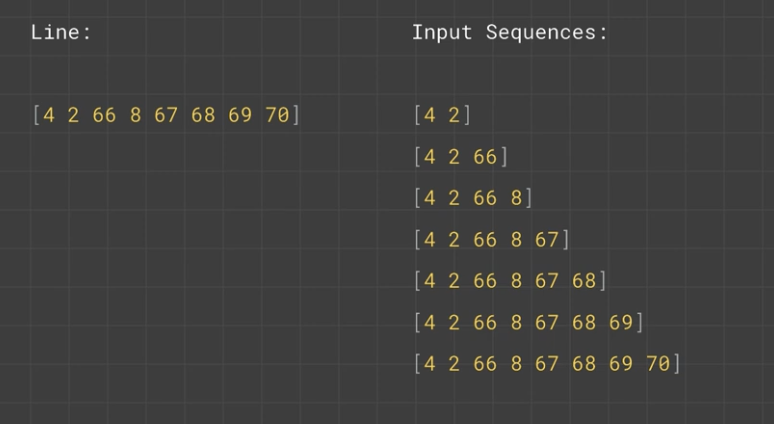

* We pad our sequences

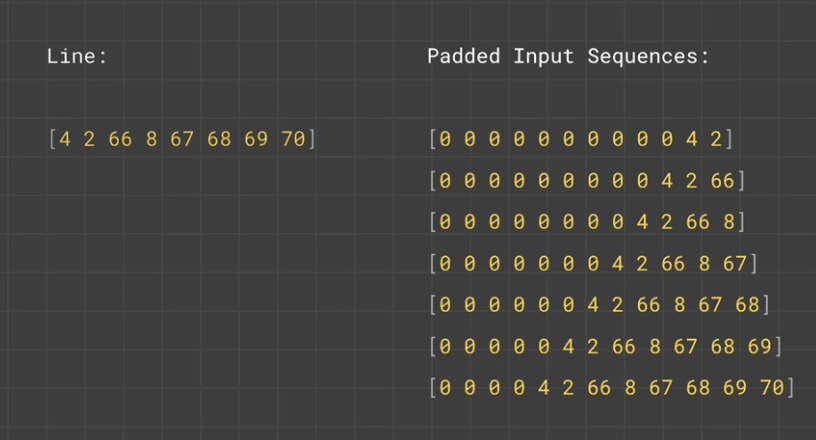

* Our set of input sequences for this ONE LINE(so far) can give us features and labels.
  - Take everything but the last value as our 'x'. and the last value as 'y'.

  - EX: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 2]
    - When we see a bunch of '0's followed by a '4', the label will be 2.

  - EX: [0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 2, 66]
    - When we see a bunch of '0's followed by a '4' and '2', the label will be 66.

  - EX: [0, 0, 0, 0, 0, 0, 0, 0, 4, 2, 66, 88]
    - When we see a bunch of '0's followed by a '4', '2', and '66', the label will be 8.

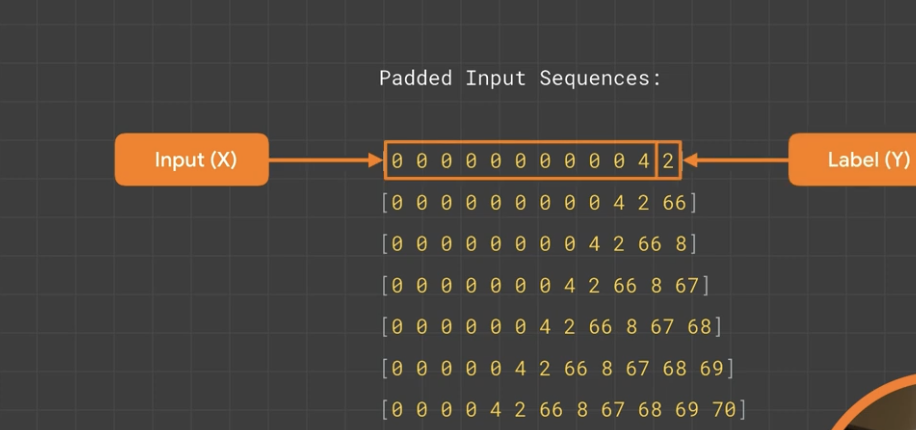

In [6]:
print(tokenizer.word_index['in'])
print(tokenizer.word_index['the'])
print(tokenizer.word_index['town'])
print(tokenizer.word_index['of'])
print(tokenizer.word_index['athy'])
print(tokenizer.word_index['one'])
print(tokenizer.word_index['jeremy'])
print(tokenizer.word_index['lanigan'])

8
1
71
6
713
39
1790
1791


In [7]:
print(xs[6])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 2]


In [8]:
print(ys[6])

[0. 0. 0. ... 0. 0. 0.]


In [9]:
print(xs[5])
print(ys[5])

[   0    0    0    0    0    0    0    0    0   51   12   96 1217   48
    2]
[0. 0. 0. ... 0. 0. 0.]


In [10]:
print(tokenizer.word_index)

{'the': 1, 'and': 2, 'i': 3, 'to': 4, 'a': 5, 'of': 6, 'my': 7, 'in': 8, 'me': 9, 'for': 10, 'you': 11, 'all': 12, 'was': 13, 'she': 14, 'that': 15, 'on': 16, 'with': 17, 'her': 18, 'but': 19, 'as': 20, 'when': 21, 'love': 22, 'is': 23, 'your': 24, 'it': 25, 'will': 26, 'from': 27, 'by': 28, 'they': 29, 'be': 30, 'are': 31, 'so': 32, 'he': 33, 'old': 34, 'no': 35, 'oh': 36, 'ill': 37, 'at': 38, 'one': 39, 'his': 40, 'there': 41, 'were': 42, 'heart': 43, 'down': 44, 'now': 45, 'we': 46, 'where': 47, 'young': 48, 'never': 49, 'go': 50, 'come': 51, 'then': 52, 'did': 53, 'not': 54, 'said': 55, 'away': 56, 'their': 57, 'sweet': 58, 'them': 59, 'green': 60, 'if': 61, 'take': 62, 'our': 63, 'like': 64, 'night': 65, 'day': 66, 'o': 67, 'out': 68, 'fair': 69, 'this': 70, 'town': 71, 'have': 72, 'can': 73, 'true': 74, 'its': 75, 'thou': 76, 'see': 77, 'dear': 78, 'more': 79, 'theres': 80, 'or': 81, 'had': 82, 'would': 83, 'over': 84, 'hear': 85, 'up': 86, 'ive': 87, 'through': 88, 'home': 89, '

In [12]:
model = Sequential()
model.add(Embedding(total_words, 100, input_length=max_sequence_len-1))
model.add(Bidirectional(LSTM(150)))
model.add(Dense(total_words, activation='softmax'))
adam = Adam(learning_rate=0.01)
model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
#earlystop = EarlyStopping(monitor='val_loss', min_delta=0, patience=5, verbose=0, mode='auto')
history = model.fit(xs, ys, epochs=100, verbose=1)
#print model.summary()
print(model)


/Users/svenwu/Hustle/MachineLearning/venv-tf/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.0758 - loss: 6.6294
Epoch 2/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.1116 - loss: 5.7657
Epoch 3/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.1496 - loss: 5.2363
Epoch 4/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.1617 - loss: 5.7783
Epoch 5/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.2302 - loss: 4.2009
Epoch 6/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.3251 - loss: 3.3975
Epoch 7/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.4100 - loss: 2.7426
Epoch 8/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.4841 - loss: 2.3138
Epoch 9/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.5418 - loss: 2.0318
Epoch 10/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.5881 - loss: 1.8072
Epoch 11/100
377/377 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6231 - loss: 1.6325
Epoch 12/100
377/377 ━━━━━━━━

In [13]:
import matplotlib.pyplot as plt


def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.show()

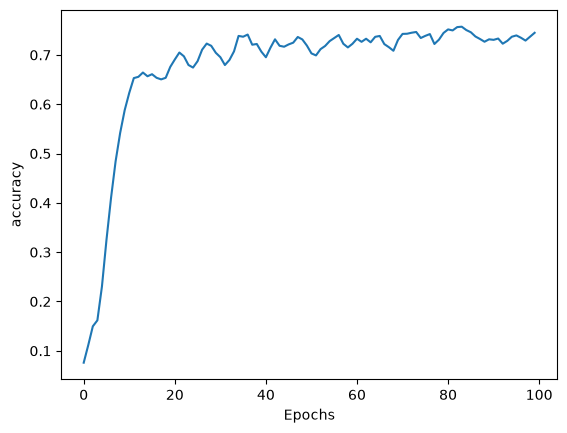

In [14]:
plot_graphs(history, 'accuracy')


In [15]:
seed_text = "I've got a bad feeling about this"
next_words = 100
  
for _ in range(next_words):
	token_list = tokenizer.texts_to_sequences([seed_text])[0]
	token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
	predicted = np.argmax(model.predict(token_list), axis=-1)
	output_word = ""
	for word, index in tokenizer.word_index.items():
		if index == predicted:
			output_word = word
			break
	seed_text += " " + output_word
print(seed_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━